In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE, MultiDAE, loss_function, NDCG_binary_at_k_batch, Recall_at_k_batch
import datetime

In [2]:
%load_ext tensorboard

In [3]:
LOGS_BASE_PATH = os.path.join("logs")
def get_current_time():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [5]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf[["username", "id", "affinity"] + spoti.NUMERICAL_FEATURES]
df_matrix_mf["affinity"] *= 100

In [7]:
# df_matrix_mf = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)

In [8]:
df_matrix_mf = df_matrix_mf.sample(frac=1)
df_matrix_mf

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
8012,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,172438,False,{'isrc': 'USA2P2342328'},{'spotify': 'https://open.spotify.com/track/4T...,https://api.spotify.com/v1/tracks/4TtwFAgN5WEJ...,4TtwFAgN5WEJKUuMUv1hcP,...,medium_term,82.0,michelle,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
7011,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,237913,False,{'isrc': 'FR9W11907078'},{'spotify': 'https://open.spotify.com/track/0i...,https://api.spotify.com/v1/tracks/0iLicFNAMT18...,0iLicFNAMT18xb36wBrRNl,...,medium_term,10.0,brenda,2019,[french],NaT,NaN,NaN,NaN,NaN
8096,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,240133,False,{'isrc': 'JPU901401691'},{'spotify': 'https://open.spotify.com/track/1d...,https://api.spotify.com/v1/tracks/1di1C0QI6Y92...,1di1C0QI6Y92yZPYn6XYAZ,...,short_term,14.0,michelle,2015,"[japanese, pop, rock]",NaT,NaN,NaN,NaN,NaN
129,"{'album_type': 'COMPILATION', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,191133,False,{'isrc': 'USWB19903820'},{'spotify': 'https://open.spotify.com/track/22...,https://api.spotify.com/v1/tracks/22VWmcVQrYqH...,22VWmcVQrYqHT4exHD6mMF,...,long_term,42.0,jaslkh,1990,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
10287,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,293333,True,{'isrc': 'FR9W11501633'},{'spotify': 'https://open.spotify.com/track/70...,https://api.spotify.com/v1/tracks/70RcHWBpd2LE...,70RcHWBpd2LEDXeX6Pua64,...,short_term,20.0,paul,2015,"[rap, rap, pop, rap, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6991,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,[],1,227026,False,{'isrc': 'QM2PV1803628'},{'spotify': 'https://open.spotify.com/track/0H...,https://api.spotify.com/v1/tracks/0HDO6JFfplYP...,0HDO6JFfplYPrSWuufUosZ,...,medium_term,50.0,brenda,2021,"[indie, pop]",NaT,NaN,NaN,NaN,NaN
7525,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,[],1,167839,False,{'isrc': 'QZTBB2226986'},{'spotify': 'https://open.spotify.com/track/3I...,https://api.spotify.com/v1/tracks/3I8kkT6YNoyT...,3I8kkT6YNoyTwhv1ycksaW,...,long_term,4.0,arthur,2022,[],NaT,NaN,NaN,NaN,NaN
1618,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,171560,False,{'isrc': 'FR3IV2100240'},{'spotify': 'https://open.spotify.com/track/41...,https://api.spotify.com/v1/tracks/41xe9FFSTjjq...,41xe9FFSTjjqzoKAoH87Gv,...,long_term,74.0,owen,2022,"[pop, french]",NaT,NaN,NaN,NaN,NaN
10344,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,153600,True,{'isrc': 'QM4DW1705205'},{'spotify': 'https://open.spotify.com/track/6x...,https://api.spotify.com/v1/tracks/6xIDZPcKh7x0...,6xIDZPcKh7x070OUZkt7Fr,...,long_term,6.0,paul,2017,"[rap, pop, rap]",NaT,NaN,NaN,NaN,NaN


In [9]:
matrix_mf = MatrixDataset(df_matrix_mf, "username", "id", "affinity", device=device, dtype=dtype)
user_interacted_with = matrix_mf.R
user_interacted_with

tensor([[ 0.,  0., 62.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0., 84.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [44., 60.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ..., 92.,  0.,  0.]], device='mps:0')

In [10]:
user_interacted_with.shape

torch.Size([8, 923])

In [11]:
alpha = matrix_mf.compute_alpha().item()
user_interacted_with *= alpha
alpha

0.10527777671813965

In [12]:
n_users, n_items = user_interacted_with.shape

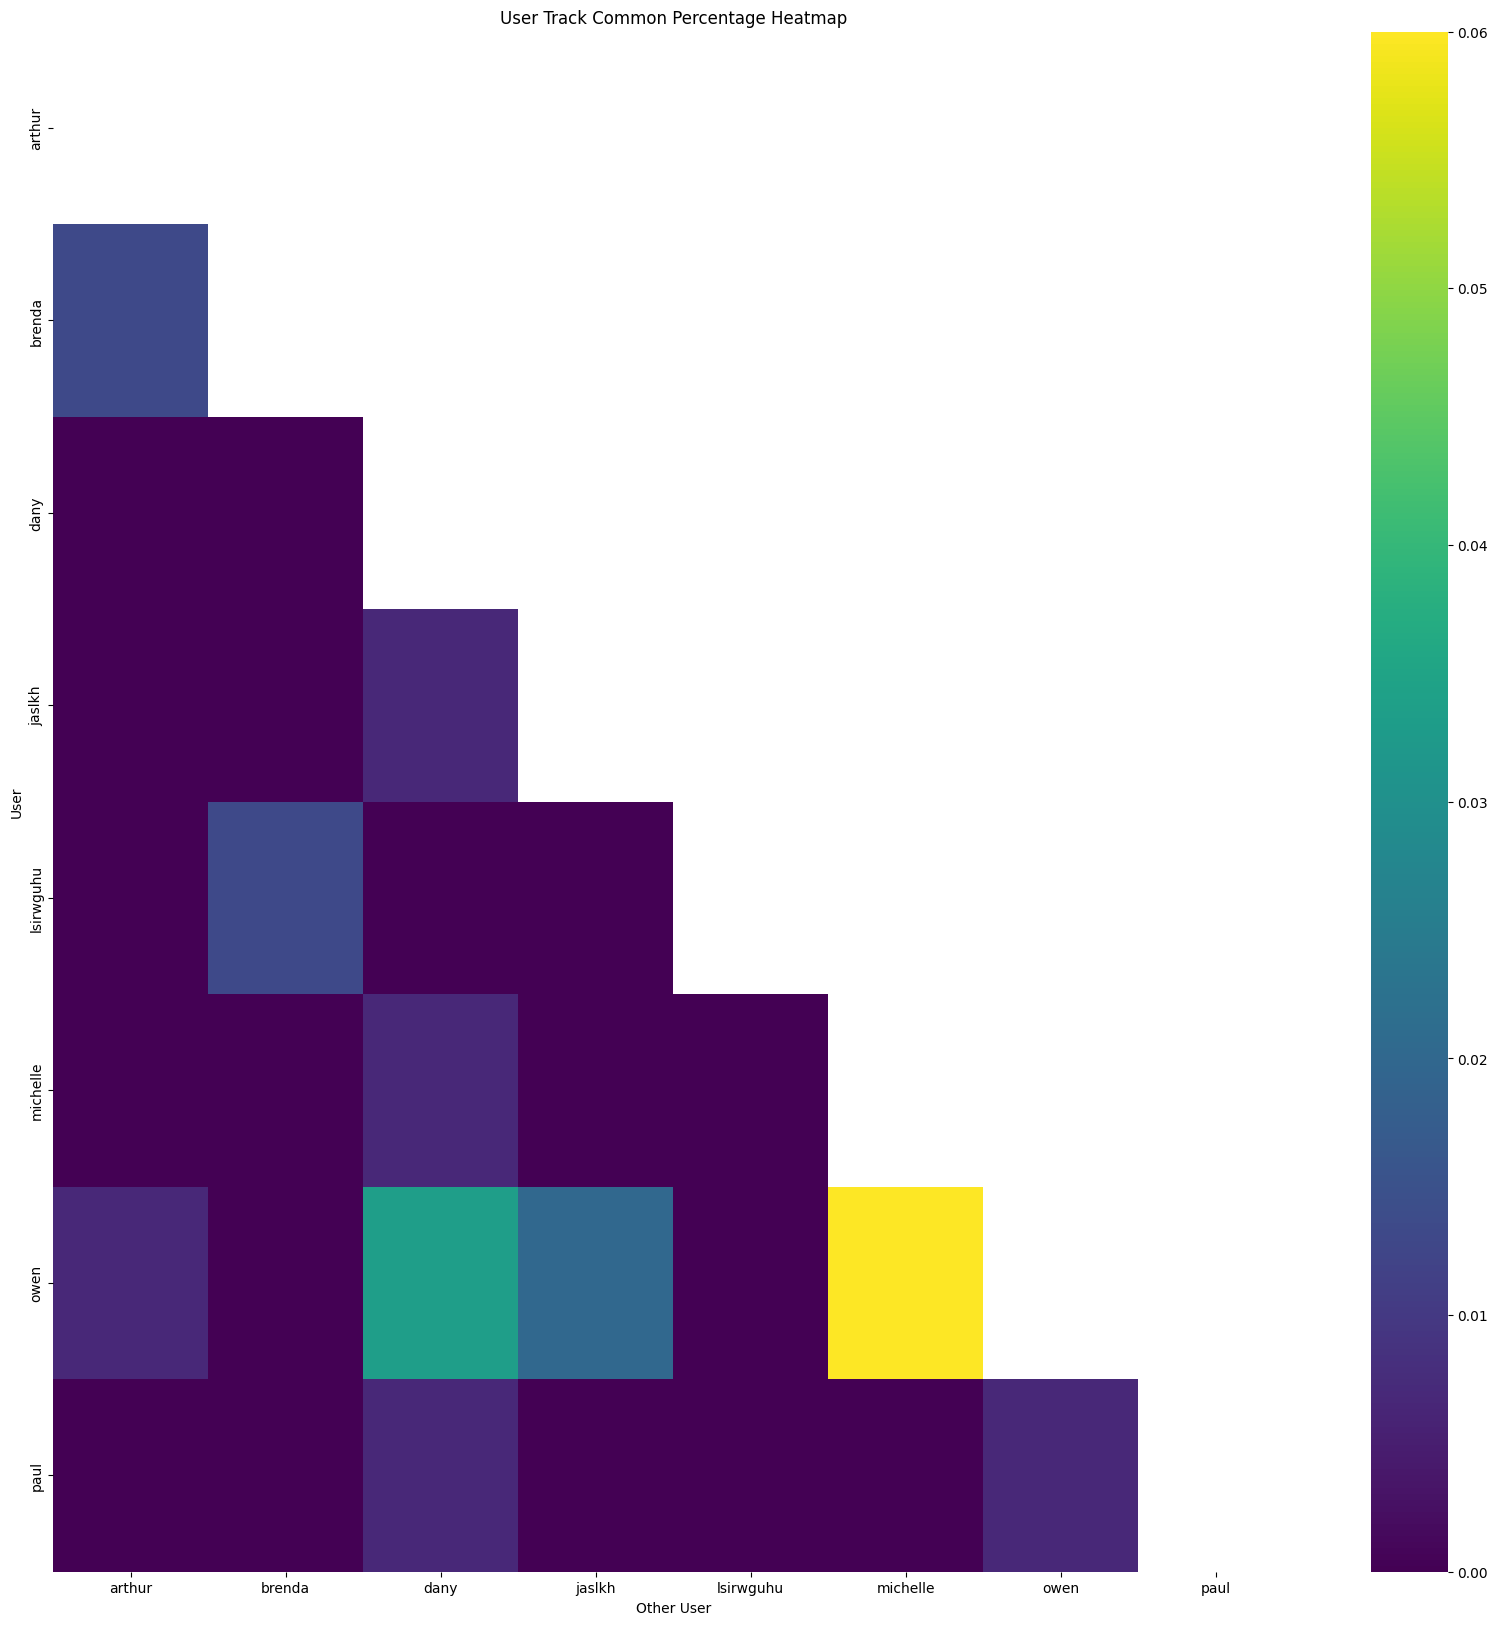

In [13]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(df_matrix_mf, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20))

# Define and train the MultiVAE model

In [14]:
user_interacted_with

tensor([[0.0000, 0.0000, 6.5272,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 8.8433],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [4.6322, 6.3167, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 9.6856, 0.0000, 0.0000]],
       device='mps:0')

In [15]:
size = user_interacted_with.shape[0]
develop_percentage = 1
train_percentage = 1

develop_set = user_interacted_with[:int(size * develop_percentage)]
train_set = develop_set[:int(develop_set.shape[0] * train_percentage)]
validation_set = develop_set[int(develop_set.shape[0] * train_percentage):]
test_set = user_interacted_with[int(size * develop_percentage):]

train_dataset = TensorDataset(train_set)
validation_dataset = TensorDataset(validation_set)
test_dataset = TensorDataset(test_set)

print(f"Develop set shape: {develop_set.shape}")
print(f"Train set shape: {train_set.shape}")
print(f"Validation set shape: {validation_set.shape}")
print(f"Test set shape: {test_set.shape}")

Develop set shape: torch.Size([8, 923])
Train set shape: torch.Size([8, 923])
Validation set shape: torch.Size([0, 923])
Test set shape: torch.Size([0, 923])


In [16]:
p_dims = [200, 600, n_items]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)

In [17]:
batch_size = 1
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
model.train_model(
    optimizer,
    train_loader,
    num_epochs=100,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    summary_writer=summary_writer
)

Epoch 1 Loss: 5593.990234375
Epoch 11 Loss: 3816.2990112304688
Epoch 21 Loss: 3753.1022338867188
Epoch 31 Loss: 3753.4405822753906
Epoch 41 Loss: 3743.0650329589844
Epoch 51 Loss: 3740.5302124023438
Epoch 61 Loss: 3745.080322265625
Epoch 71 Loss: 3718.5787963867188
Epoch 81 Loss: 3690.5149536132812
Epoch 91 Loss: 3683.080810546875


In [18]:
if len(test_set) > 0:
    total_loss, n100_list, r20_list, r50_list = model.evaluate_model(
        training_set=train_set,
        test_set=test_set,
        batch_size=batch_size,
        anneal_cap=anneal_cap,
        total_anneal_steps=total_anneal_steps,
        device=device,
        dtype=dtype,
        summary_writer=summary_writer
    )
    print(f"Total loss: {total_loss}")
    print(f"n100_list: {n100_list}")
    print(f"r20_list: {r20_list}")
    print(f"r50_list: {r50_list}")

In [19]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['arthur', 'brenda', 'dany', 'jaslkh', 'lsirwguhu', 'michelle', 'owen', 'paul']

In [20]:
z, mu, std, logvar = model.get_latent_representations(user_interacted_with)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])


In [21]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(0, 5)
dim2 = range(0, 5)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

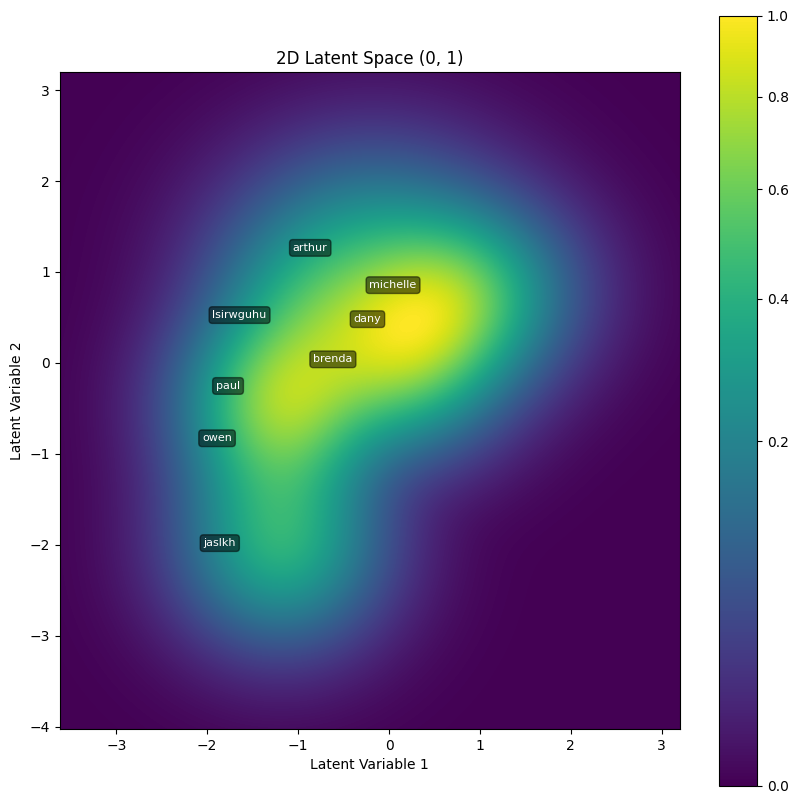

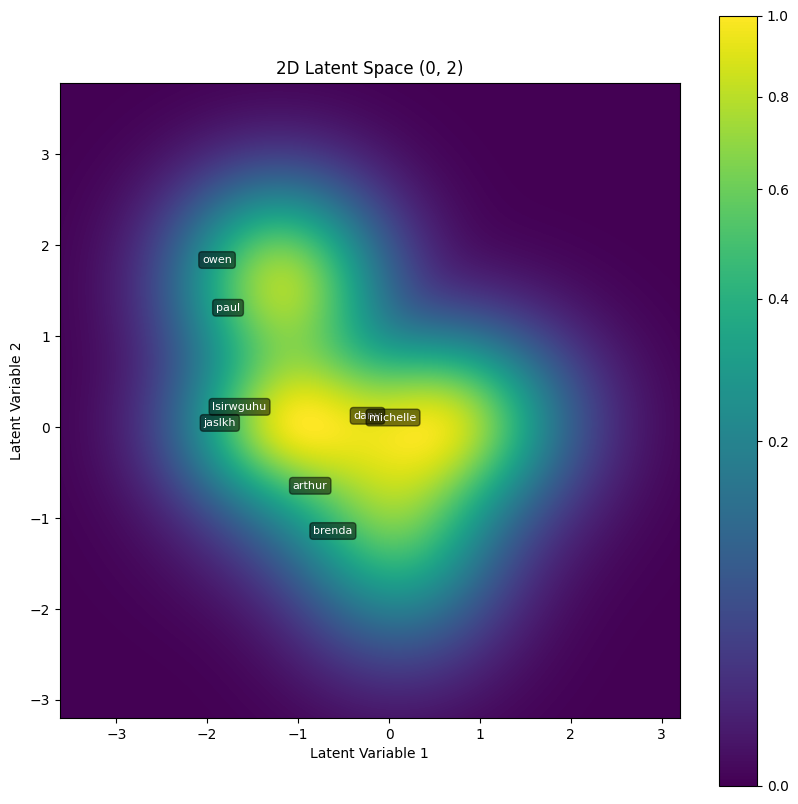

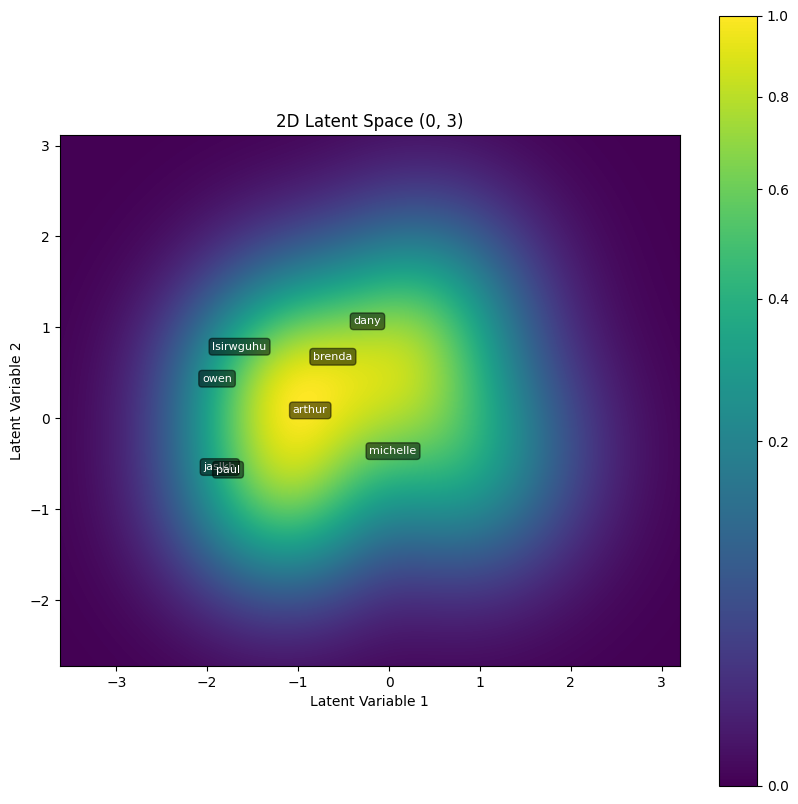

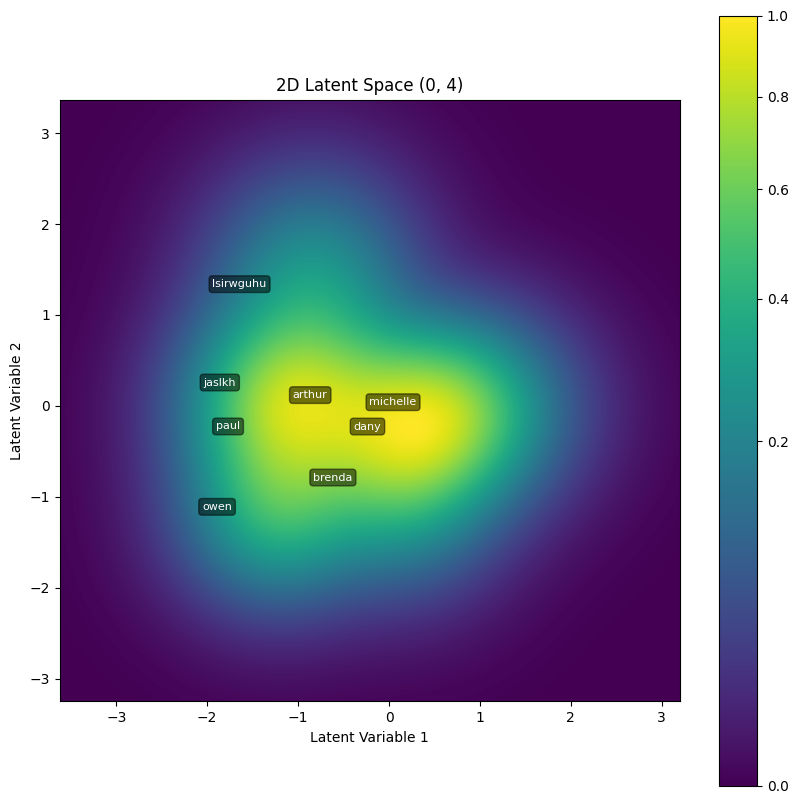

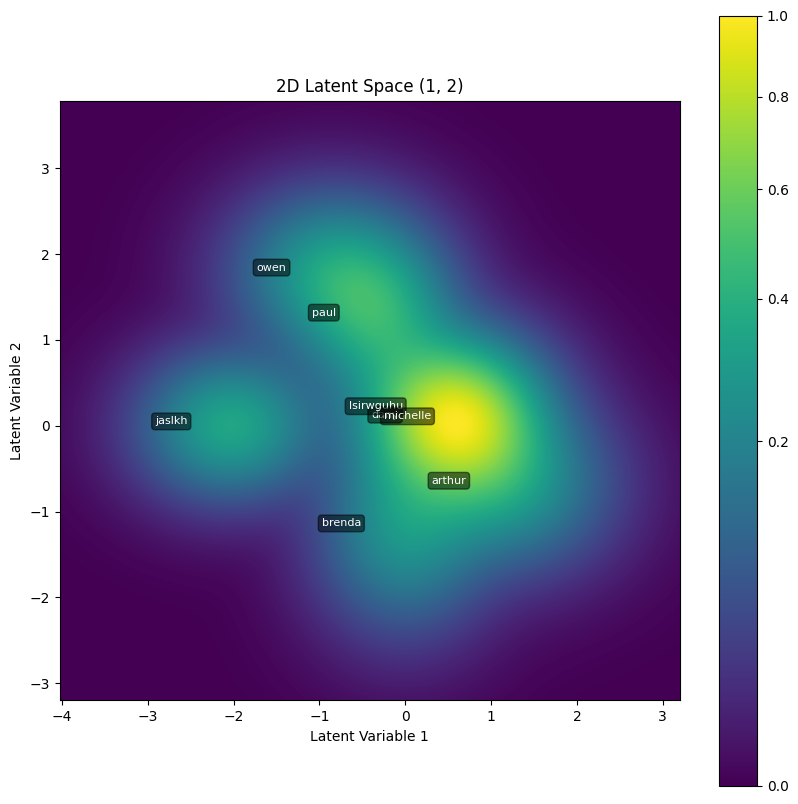

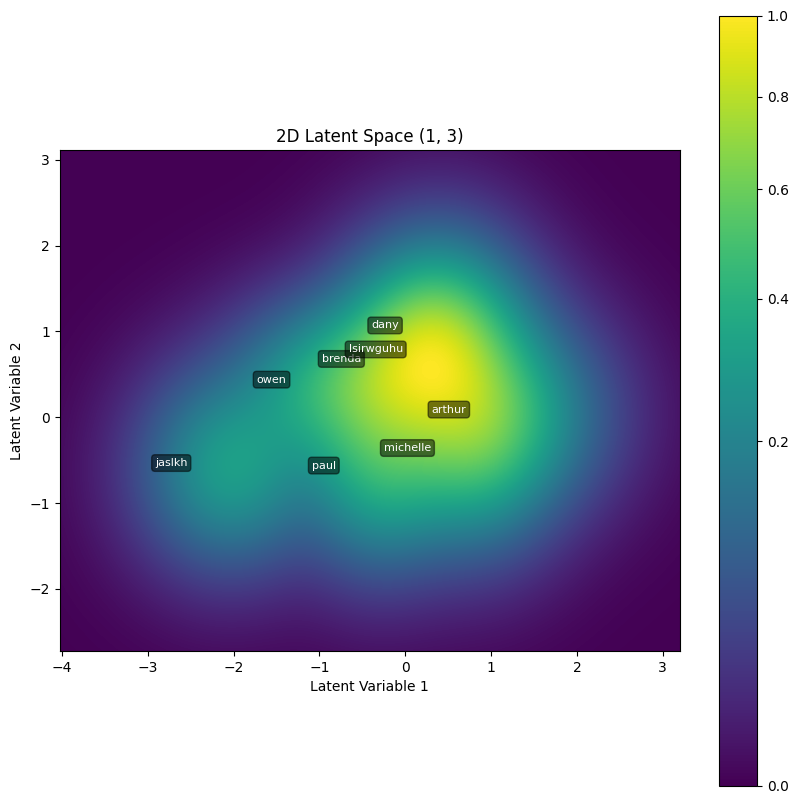

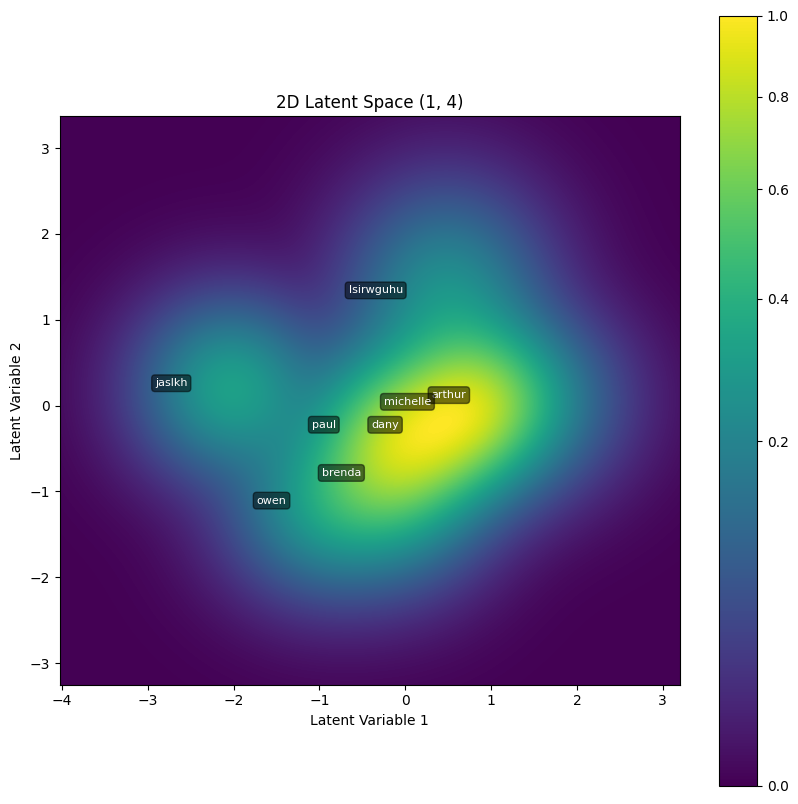

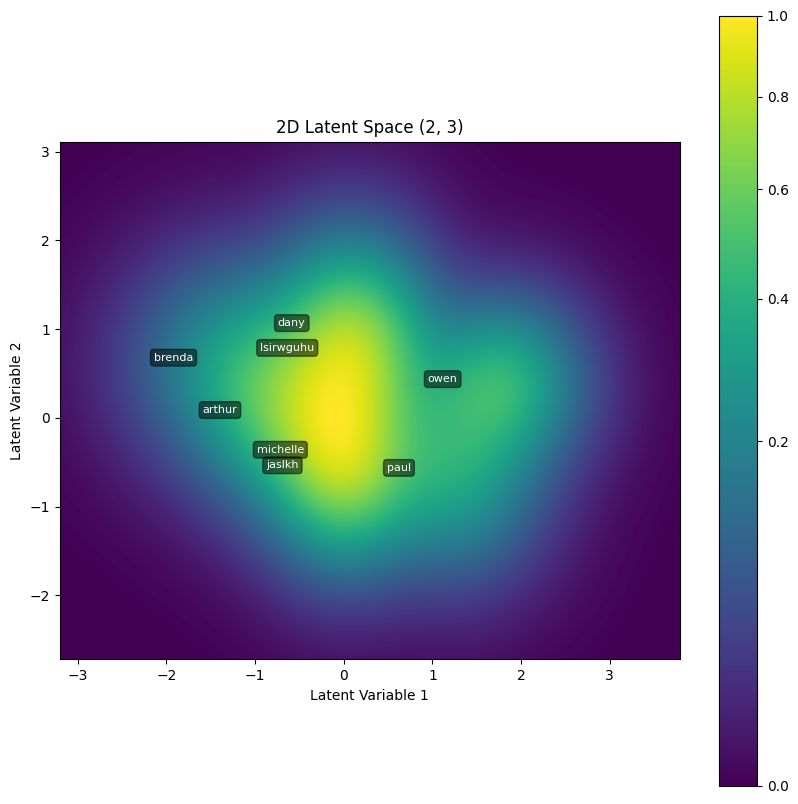

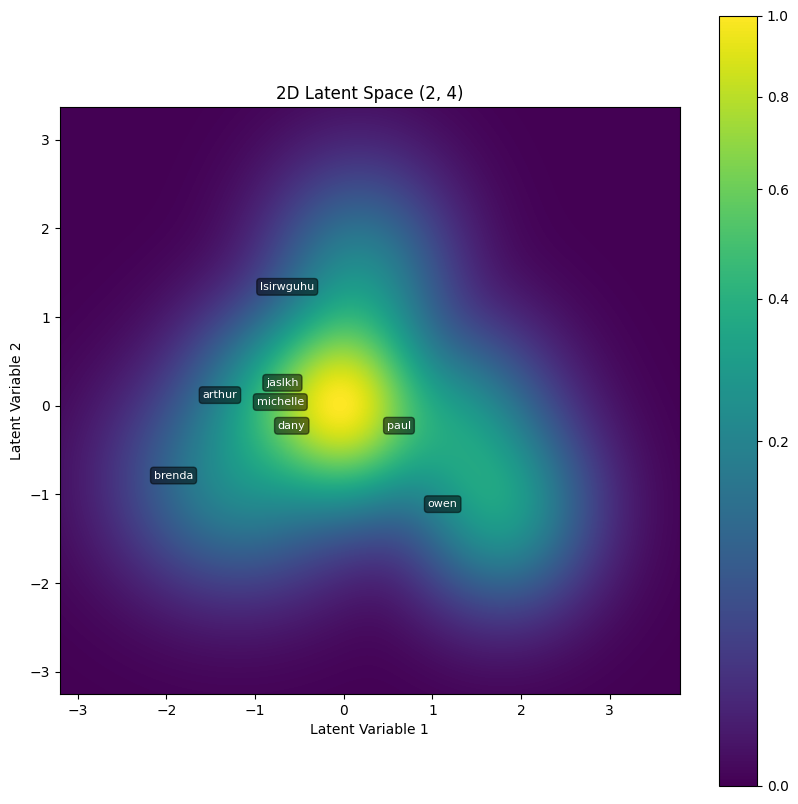

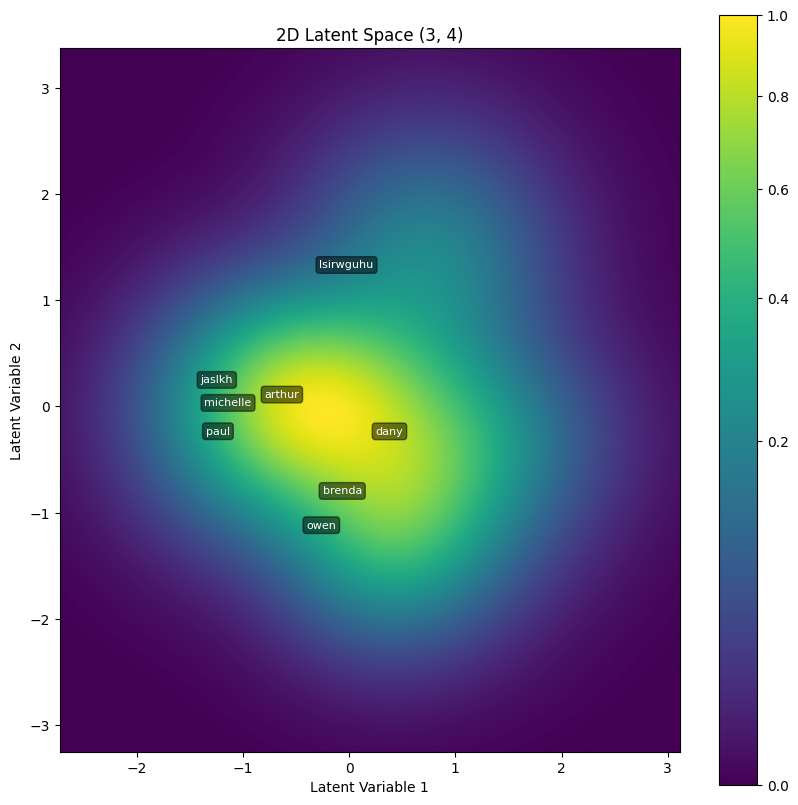

In [22]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [32]:
username = "michelle"
user_id = matrix_mf.usernames_to_ids([username])[0]
print(f"User id: {user_id}")
user_seen = matrix_mf.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: 5


(121,)

In [33]:
similar_users_ids = model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = matrix_mf.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['owen', 'arthur', 'lsirwguhu', 'brenda', 'jaslkh', 'paul', 'dany']

In [34]:
items_ids = model.recommend(matrix=user_interacted_with)
recommendation_df = matrix_mf.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)
# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df.drop_duplicates(subset=["id"], inplace=True)
recommendation_df[spoti.PRETTY_PRINT_FEATURES].head(40)

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
item_id,,,,,,,,,,,,,,,,,
857,owen,Edwin Rosen,21 Nächte wach,2022,59,0.660,0.9740,0.0643,0.01030,0.155000,0.0542,0.9560,161.954,-6.564,162962,2022,59
543,dany,Harry Styles,As It Was,2022,60,0.520,0.7310,0.0557,0.34200,0.001010,0.3110,0.6620,173.930,-5.338,167303,2022,60
241,owen,MCR-T,1-800-GHETTOLICIOUS,2023,46,0.875,0.8370,0.1480,0.00143,0.045200,0.1450,0.8140,136.994,-8.386,262773,2023,46
272,owen,Mistress,Liminal,2022,24,0.467,0.6990,0.0353,0.64700,0.871000,0.1040,0.1940,161.968,-8.140,213333,2022,24
574,owen,Mietze Conte,nanana,2022,52,0.536,0.8970,0.0497,0.00455,0.852000,0.3310,0.1860,179.990,-7.834,122666,2022,52
290,owen,Citizen,How Does It Feel?,2013,57,0.406,0.5770,0.0351,0.00180,0.510000,0.4910,0.3820,83.456,-5.864,233436,2013,57
898,arthur,Queen,Cool Cat - Remastered 2011,1982,64,0.818,0.4000,0.1100,0.30200,0.002410,0.1800,0.8380,73.760,-9.927,209106,1982,64
58,paul,Fetty Wap,Trap Queen,2015,62,0.746,0.8730,0.1200,0.02440,0.000000,0.3560,0.8160,148.075,-3.803,222128,2015,62
509,arthur,Lost Frequencies,Are You With Me,2016,81,0.763,0.6080,0.0350,0.26200,0.000025,0.1200,0.3930,121.020,-8.100,138013,2016,81
